In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")


In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
df.groupby("Outcome").mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

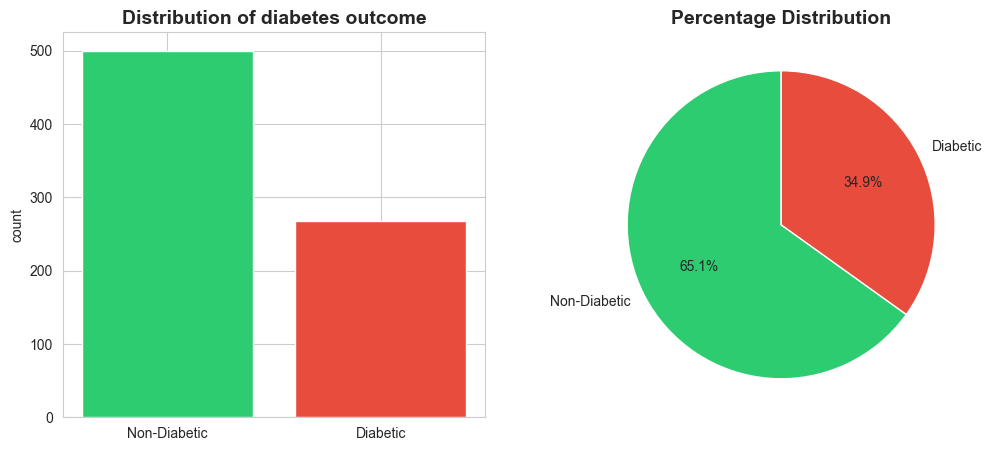

In [10]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
outcome_counts=df["Outcome"].value_counts()
plt.bar(["Non-Diabetic","Diabetic"],outcome_counts.values,color=["#2ecc71",'#e74c3c'])
plt.title("Distribution of diabetes outcome", fontsize=14,fontweight="bold")
plt.ylabel("count")


plt.subplot(1,2,2)
plt.pie(outcome_counts.values,labels=["Non-Diabetic","Diabetic"],
        autopct="%1.1f%%",colors=["#2ecc71","#e74c3c"],startangle=90)
plt.title("Percentage Distribution", fontsize=14, fontweight="bold")
plt.show()


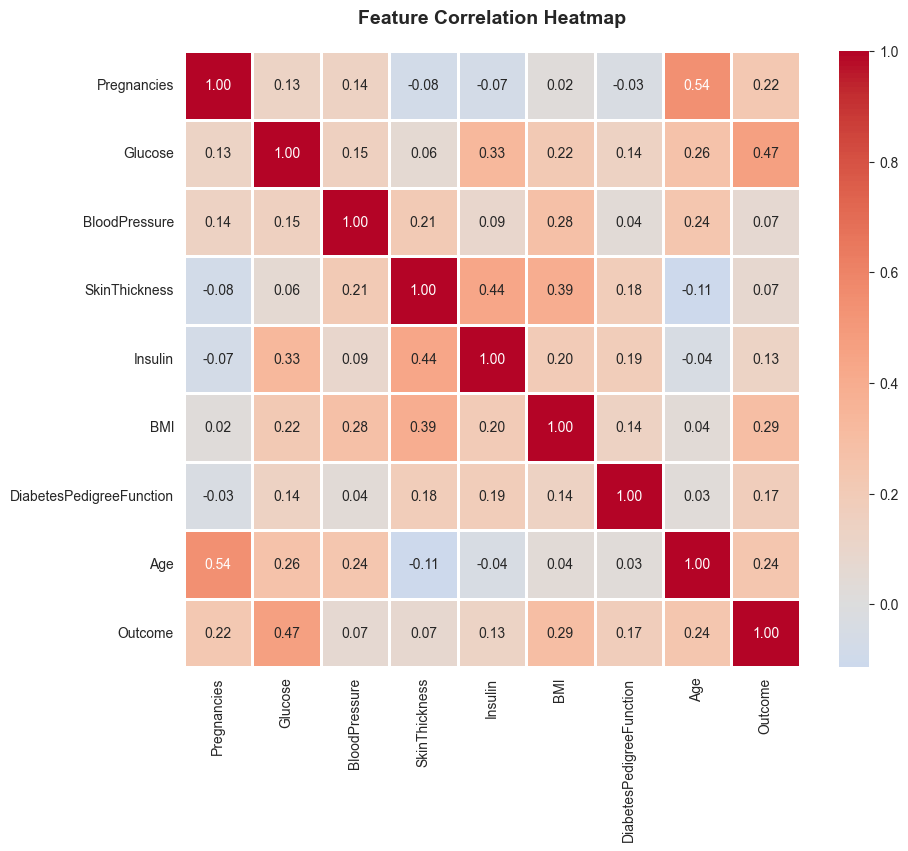

In [11]:
## corellation heat map

plt.figure(figsize=(10,8))
correlation = df.corr()
sns.heatmap(correlation,annot=True,cmap="coolwarm",center=0,square=True,linewidth=1,fmt=".2f")
plt.title("Feature Correlation Heatmap",fontsize=14,pad=20,fontweight="bold")
plt.show()

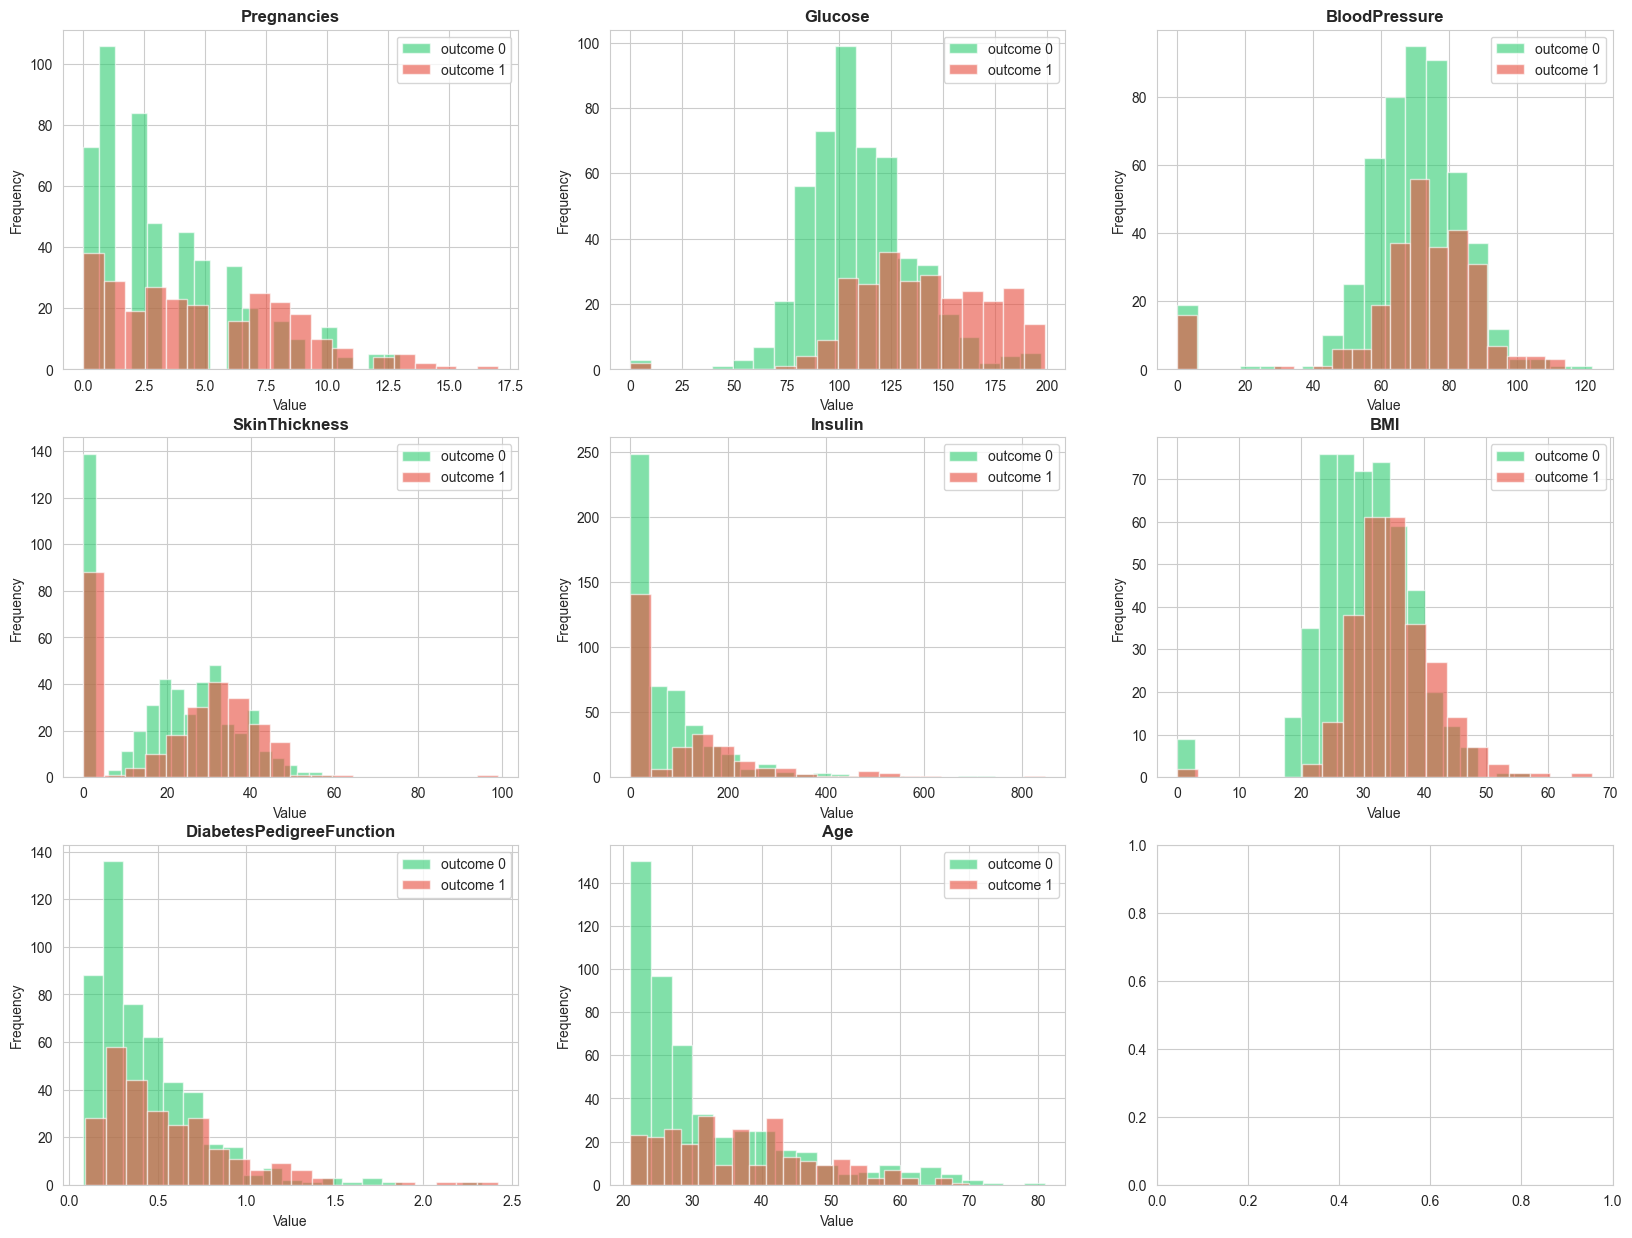

In [12]:
fig, axes =plt.subplots(3,3,figsize=(20,15))
features = df.columns[:-1]


for idx, features in enumerate(features):
    row,col=idx //3,idx % 3
    for outcome in [0,1]:
        data = df[df["Outcome"] == outcome][features]
        axes[row,col].hist(data,alpha=0.6,bins=20, label=f"outcome {outcome}",
                           color=["#2ecc71","#e74c3c"][outcome])
        axes[row,col].set_title(features,fontweight="bold")
        axes[row,col].set_xlabel("Value")
        axes[row,col].set_ylabel("Frequency")
        axes[row,col].legend()
plt.show()

In [13]:
## Data perprocessing

x=df.drop(columns="Outcome",axis=1)
y=df["Outcome"]

print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [14]:
## Standardization
scaler=StandardScaler()
x=scaler.fit_transform(x)
x

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [16]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)
print(x.shape,x_train.shape,x_test.shape)

(768, 8) (614, 8) (154, 8)


In [18]:
## train model
classifier=svm.SVC(kernel="linear",probability=True)
classifier.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [19]:
x_train_prediction = classifier.predict(x_train)
training_data_accuracy=accuracy_score(x_train_prediction,y_train)
training_data_accuracy

0.7866449511400652

In [20]:
x_test_prediction=classifier.predict(x_test)
test_data_accuracy=accuracy_score(x_test_prediction,y_test)
test_data_accuracy

0.7727272727272727

In [22]:
precision=precision_score(y_test,x_test_prediction)
recall=recall_score(y_test,x_test_prediction)
f1=f1_score(y_test,x_test_prediction)

print(precision, recall, f1)

0.7567567567567568 0.5185185185185185 0.6153846153846154


In [23]:
cm_svm=confusion_matrix(y_test,x_test_prediction)
cm_svm

array([[91,  9],
       [26, 28]])

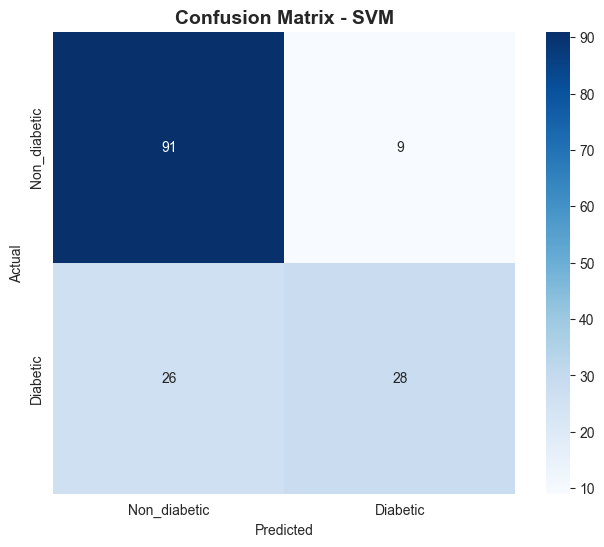

In [25]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_svm,annot=True,fmt="d",cmap="Blues",square= True,
            xticklabels=["Non_diabetic", "Diabetic"],
            yticklabels=["Non_diabetic", "Diabetic"])
plt.title("Confusion Matrix - SVM",fontsize=14,fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Trainig the Random Forest model

In [26]:
rf_classifire=RandomForestClassifier(n_estimators=100, random_state=2)
rf_classifire.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
x_train_prediction_rf=rf_classifire.predict(x_train)

In [31]:
training_data_accuracy_rf=accuracy_score(x_train_prediction_rf,y_train)
training_data_accuracy_rf

1.0

In [32]:
x_test_prediction_rf=rf_classifire.predict(x_test)
test_data_accuracy_rf=accuracy_score(x_test_prediction_rf,y_test)

In [33]:
test_data_accuracy_rf

0.7272727272727273

In [34]:
precision_rf=precision_score(y_test,x_test_prediction_rf)
recall_rf=recall_score(y_test,x_test_prediction_rf)
f1_rf=f1_score(y_test,x_test_prediction_rf)

print(precision_rf, recall_rf, f1_rf)

0.65 0.48148148148148145 0.5531914893617021


In [35]:
cm_rf=confusion_matrix(y_test,x_test_prediction_rf)
cm_rf

array([[86, 14],
       [28, 26]])

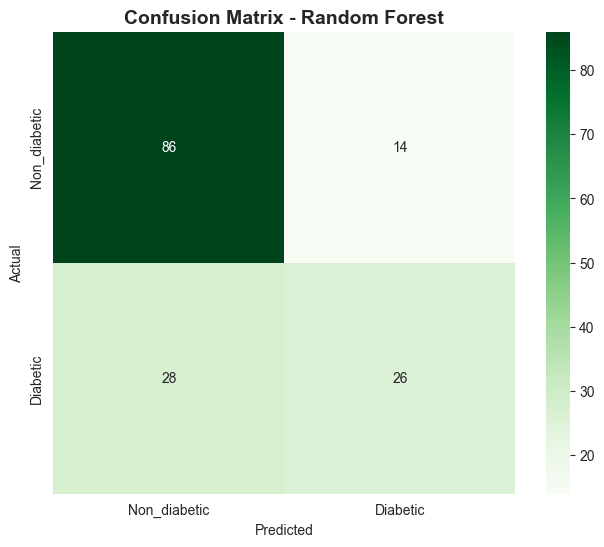

In [38]:
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Greens",square= True,
            xticklabels=["Non_diabetic", "Diabetic"],
            yticklabels=["Non_diabetic", "Diabetic"])
plt.title("Confusion Matrix - Random Forest",fontsize=14,fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [40]:
print("SVM",test_data_accuracy)
print("Random Forest",test_data_accuracy_rf)

SVM 0.7727272727272727
Random Forest 0.7272727272727273


In [41]:
joblib.dump(classifier,"diabetes_model.pkl")

['diabetes_model.pkl']

In [44]:
input_data = (5,166,72,19,175,25.8,0.587,51)
input_num_array=np.array(input_data)
reshape = input_num_array.reshape(1,-1)

std_data=scaler.transform(reshape)
prediction = classifier.predict(std_data)

In [45]:
prediction

array([1])